### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
#print(df)
#print(df.filter(items = ["wine_servings", "beer_servings", "spirit_servings"]))
#print(df.sort_values(by = "total_litres_of_pure_alcohol", ascending=False)[0:10])
#print(df)
#print(np.mean(df["wine_servings"]))
media_vino = df["wine_servings"].mean()
media_birra = df["beer_servings"].mean()
media_distillati = df["spirit_servings"].mean()

new_column = pd.array(((df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3))
#print(new_column)
df["alchol_index"] = new_column
#print(df)
print(df.loc[(np.argmax(df["alchol_index"]))].filter(items = ["country"]))
print(df.loc[df["beer_servings"] > 100].filter(items = ["country"]))


country    Andorra
Name: 3, dtype: object
               country
3              Andorra
4               Angola
5    Antigua & Barbuda
6            Argentina
8            Australia
..                 ...
182     United Kingdom
184                USA
185            Uruguay
188          Venezuela
189            Vietnam

[79 rows x 1 columns]


### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [3]:
import pandas as pd
from datasets import load_dataset

# #lista = list(np.unique(np.asarray(df["job_country"])))
# #lista

c:\Users\chris\miniconda3\envs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

paesi_salario_medio = df.groupby("job_country")["salary_year_avg"].mean(skipna=True)

print(paesi_salario_medio)

job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64


In [5]:
array_na = pd.isna(df["salary_year_avg"])

print((df[["job_country", "salary_year_avg"]][pd.isna(df["salary_year_avg"])]))

          job_country  salary_year_avg
0       United States              NaN
1              Mexico              NaN
2             Germany              NaN
3       United States              NaN
4               Sudan              NaN
...               ...              ...
785736      Singapore              NaN
785737        Germany              NaN
785738       Malaysia              NaN
785739          Sudan              NaN
785740          India              NaN

[763738 rows x 2 columns]


In [6]:
paesi_numero_offerte = df.groupby("job_country")["job_country"].count()
print(paesi_numero_offerte)

job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Name: job_country, Length: 160, dtype: int64


In [7]:
paesi = df.groupby('job_country').groups.keys()
print(paesi)
paesi = pd.Series(paesi)
print(paesi)

dict_keys(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands', 'Chile', 'China', 'Colombia', 'Congo, Democratic Republic of the', 'Costa Rica', 'Croatia', 'Curaçao', 'Cyprus', 'Czechia', "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gambia', 'Germany', 'Ghana', 'Greece', 'Guadeloupe', 'Guam', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembo

In [8]:
paesi_stipendio_min = df.groupby("job_country")["salary_year_avg"].min()
paesi_stipendio_max = df.groupby("job_country")["salary_year_avg"].max()
#print(type(paesi_stipendio_max))
paesi_stipendio_intervallo = pd.concat([paesi_stipendio_min, paesi_stipendio_max], axis = 1)
#print(paesi_stipendio_min)

print(paesi_stipendio_intervallo)

             salary_year_avg  salary_year_avg
job_country                                  
Afghanistan              NaN              NaN
Albania              43200.0         157500.0
Algeria              44100.0          45000.0
Angola                   NaN              NaN
Argentina            45000.0         222000.0
...                      ...              ...
Venezuela                NaN              NaN
Vietnam              28000.0         200000.0
Yemen                    NaN              NaN
Zambia               90670.0          90670.0
Zimbabwe             47500.0          90670.0

[160 rows x 2 columns]


In [9]:
print(df[0:10])

print(df["job_country"])
print(df.columns)

        job_title_short                                          job_title  \
0  Senior Data Engineer  Senior Clinical Data Engineer / Principal Clin...   
1          Data Analyst                                       Data Analyst   
2         Data Engineer  Data Engineer/Scientist/Analyst, Mid or Senior...   
3         Data Engineer  LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...   
4         Data Engineer                             Data Engineer- Sr Jobs   
5         Data Engineer                                  GCP Data Engineer   
6  Senior Data Engineer                  Senior Data Engineer  - GCP Cloud   
7         Data Engineer                                      Data Engineer   
8      Business Analyst           Technology & Operations Business Analyst   
9        Data Scientist                                  Data Scientist II   

                   job_location             job_via         job_schedule_type  \
0                 Watertown, CT     via Work Nearby         

job_title_short
Business Analyst              91082.612833
Data Analyst                  93841.907854
Cloud Engineer               111268.453846
Software Engineer            113393.760054
Senior Data Analyst          113911.363665
Machine Learning Engineer    126774.315972
Data Engineer                130125.604250
Data Scientist               135988.837171
Senior Data Engineer         145840.611624
Senior Data Scientist        154206.292996
Name: salary_year_avg, dtype: float64


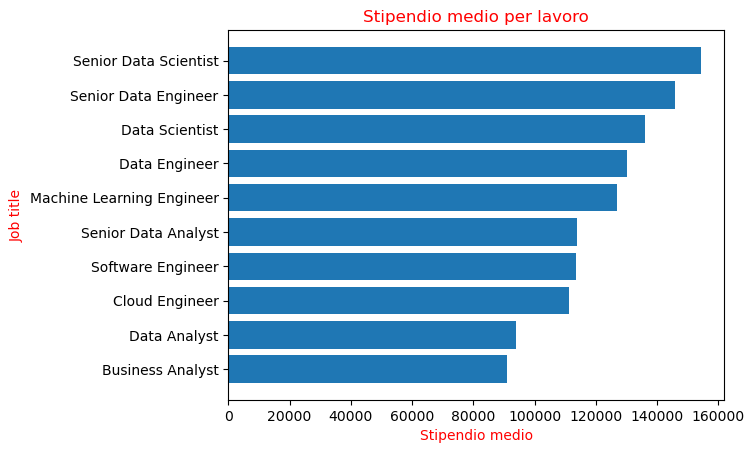

In [31]:
import matplotlib.pyplot as plt
paesi_job_plot = df.groupby('job_title_short')['salary_year_avg'].mean()
paesi_job_plot.sort_values(ascending=True, axis=0, inplace=True)
print(paesi_job_plot)
plt.barh(paesi_job_plot.index, paesi_job_plot)
#plt.barh(paesi_job_plot.keys(), paesi_job_plot.values) modo alternativo
plt.xlabel("Stipendio medio", color = "red")
plt.ylabel("Job title", color = "red")
plt.title("Stipendio medio per lavoro", color = "red")
plt.show()


### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [34]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [39]:
print(df["day"].unique())
conto_medio_per_giornata = df.groupby("day")["total_bill"].mean()
print(conto_medio_per_giornata)

<ArrowStringArray>
['Sun', 'Sat', 'Thur', 'Fri']
Length: 4, dtype: str
day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64


In [ ]:
numero_di_osservazioni_per_giornata = df.groupby("day")["day"].count()
print(numero_di_osservazioni_per_giornata)
#print(sum(numero_di_osservazioni_per_giornata))
#print(df.shape[0]) per verificare che siano tutte


day
Fri     19
Sat     87
Sun     76
Thur    62
Name: day, dtype: int64
244
244


In [ ]:
conto_max_per_giornata = df.groupby("day")["total_bill"].max()
conto_min_per_giornata = df.groupby("day")["total_bill"].min()
print(conto_max_per_giornata)
print(conto_min_per_giornata)

day
Fri     40.17
Sat     50.81
Sun     48.17
Thur    43.11
Name: total_bill, dtype: float64
day
Fri     5.75
Sat     3.07
Sun     7.25
Thur    7.51
Name: total_bill, dtype: float64


In [ ]:
df["conto_per_persona"] = df["total_bill"]/df["size"]
df.head()

,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500


In [69]:
print(conto_medio_per_giornata)
giorno_piu_costoso = conto_medio_per_giornata.idxmax()
#giorno_piu_costoso = float(giorno_piu_costoso)
print(giorno_piu_costoso, conto_medio_per_giornata[giorno_piu_costoso])

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64
Sun 21.41


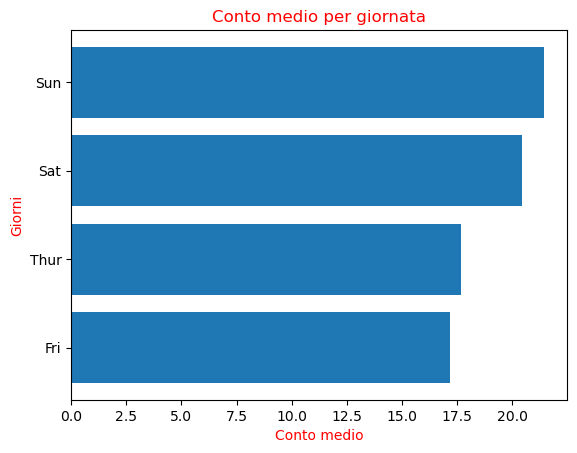

In [77]:
conto_medio_per_giornata.sort_values(inplace=True, ascending=True)
plt.barh(conto_medio_per_giornata.index, conto_medio_per_giornata)
plt.xlabel("Conto medio", color="red")
plt.ylabel("Giorni", color="red")
plt.title("Conto medio per giornata", color="red")
plt.show()